# Plane integral of charge density alon z
## We assume the cube file is in a orthogonal cell (a,b,c)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from useful_notebooks_cube import (
    bohr_to_ang,
    read_cube_full,
    z_charge_density_profile,
)

# path to cube file to be displayed

In [2]:
cube="./Downloads/charge.cube"

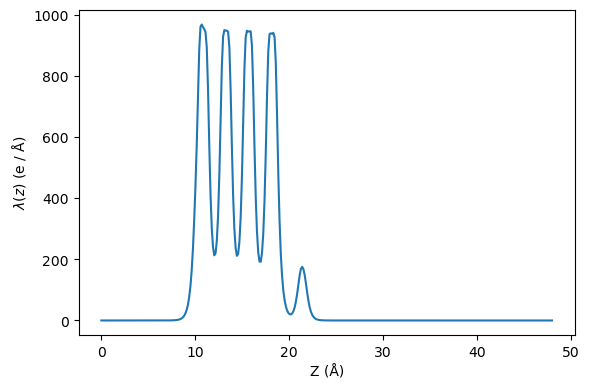

In [4]:
header_lines, atom_lines, rho, shape = read_cube_full(cube)

z_ang, lambda_z_ang = z_charge_density_profile(
    header_lines=header_lines,
    rho=rho,
    bohr_to_ang=bohr_to_ang,
)

plt.figure(figsize=(6, 4))
plt.plot(z_ang, lambda_z_ang)
plt.xlabel("Z (Å)")
plt.ylabel(r"$\lambda(z)$ (e / Å)")
plt.tight_layout()
plt.show()

# line integral

In [6]:
Q_from_z = np.trapezoid(lambda_z_ang, z_ang)
print(f"Integrated charge from z profile: {Q_from_z:.10f} e")

Integrated charge from z profile: 6151.9871725719 e


# Volume integral

In [7]:
xgrid_tokens = header_lines[3].split()
ygrid_tokens = header_lines[4].split()
zgrid_tokens = header_lines[5].split()

vx_bohr = np.array(list(map(float, xgrid_tokens[1:4])), dtype=float)
vy_bohr = np.array(list(map(float, ygrid_tokens[1:4])), dtype=float)
vz_bohr = np.array(list(map(float, zgrid_tokens[1:4])), dtype=float)

dV_bohr3 = abs(np.linalg.det(np.column_stack([vx_bohr, vy_bohr, vz_bohr])))
Q_3d = rho.sum() * dV_bohr3

print(f"Integrated charge from 3D grid: {Q_3d:.10f} e")
print(f"Difference (z-profile - 3D): {Q_from_z - Q_3d:.6e} e")

Integrated charge from 3D grid: 6151.9872948003 e
Difference (z-profile - 3D): -1.222285e-04 e
